# Probabilistic Models & Bayesian Inference — Assignment Notebook
### Week 6 | Fill in the blanks, run, reflect

---

**Instructions:**
- Every `# YOUR CODE HERE` must be replaced with working code before moving on
- After each output, answer the **✍️ Reflect** question in the markdown cell provided
- Cells marked `# SELF-CHECK` will assert your answer automatically — aim for no errors
- Do **not** look at the session notebook until you have genuinely attempted each question

> **Mindset:** The blanks are not syntax tests. Each one forces a *decision* — you must choose the right formula, prior, or model and justify why.

> **Datasets:**
> - **Telco Customer Churn** (Parts 1–4, 6): same CSV from Week 5
> - **Mauna Loa CO₂** (Part 5 only): `from statsmodels.datasets import co2` — 3 lines to load

---


In [1]:
!pip install -q pymc arviz pgmpy scikit-learn scipy statsmodels pandas numpy matplotlib seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.1/165.1 kB 7.5 MB/s eta 0:00:00


In [2]:
# Run this cell first — all imports and data loading happen here
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import beta as beta_dist, dirichlet

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ExpSineSquared, WhiteKernel, DotProduct
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pymc as pm
import arviz as az
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.parameter_estimator import DiscreteMLE
from pgmpy.inference import VariableElimination

sns.set_theme(style='whitegrid'); plt.rcParams['figure.figsize'] = [12, 5]

# seaborn sets the color cycle as RGB tuples; arviz 1.1.0's az.plot_trace can't
# reshape those into per-chain colors. Convert to hex strings (identical colors).
import matplotlib.colors as _mcolors
from cycler import cycler as _cycler
plt.rcParams['axes.prop_cycle'] = _cycler(
    color=[_mcolors.to_hex(c) for c in plt.rcParams['axes.prop_cycle'].by_key()['color']])

# ── Telco data ─────────────────────────────────────────────────────────────────
url = ("https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d"
       "/master/data/Telco-Customer-Churn.csv")
df_raw = pd.read_csv(url)
df = df_raw.copy()
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df = df.drop(columns=['customerID'])
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"Telco loaded: {df.shape}  Churn rate: {df['Churn'].mean():.3f}")


Telco loaded: (7043, 20)  Churn rate: 0.265


---
## Part 1: The Estimation Trinity — MLE, MAP, Full Bayes

**Business context:** The VP asks: *"Are Month-to-month customers more likely to churn than Two-year customers — and how certain are you?"* Three statistical frameworks give three different answers.

---

### Q1 — Extract the experimental groups

Extract Group A (Month-to-month), Group B (Two-year), and Group A_small (40 rows from A).


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [5]:
group_A       = df[df['Contract'] == 'Month-to-month']
group_B       = df[df['Contract'] == 'Two year']
group_A_small = group_A.sample(n=40, random_state=42)

k_A,  n_A  = group_A['Churn'].sum(),       len(group_A)
k_B,  n_B  = group_B['Churn'].sum(),       len(group_B)
k_As, n_As = group_A_small['Churn'].sum(), len(group_A_small)

# ── SELF-CHECK ────────────────────────────────────────────────
assert n_As == 40
assert n_A > 3000
assert n_B > 1000
print(f"Group A  (M2M):  n={n_A}, k={k_A}, rate={k_A/n_A:.4f}")
print(f"Group A_small:   n={n_As}, k={k_As}, rate={k_As/n_As:.4f}")
print(f"Group B  (2yr):  n={n_B}, k={k_B}, rate={k_B/n_B:.4f}")
print("✅ Groups extracted correctly!")

Group A  (M2M):  n=3875, k=1655, rate=0.4271
Group A_small:   n=40, k=15, rate=0.3750
Group B  (2yr):  n=1695, k=48, rate=0.0283
✅ Groups extracted correctly!


### Q2 — Compute MLE, MAP, and plot all three posteriors

Use a **Beta(2, 8) prior** (encodes belief that most segments churn < 30%).


In [6]:
alpha_prior, beta_prior = 2, 8   # Beta(2, 8) prior — do not change

groups = {
    'Group A (M2M, large)': (k_A,  n_A),
    'Group A_small (n=40)': (k_As, n_As),
    'Group B (2yr, large)': (k_B,  n_B),
}

print(f"{'Group':<30} {'MLE':>8} {'MAP':>8} {'|MAP-MLE|':>12}")
print("-" * 62)
for name, (k, n) in groups.items():
    mle     = k / n
    map_est = (alpha_prior + k - 1) / (alpha_prior + beta_prior + n - 2)
    pull    = abs(map_est - mle)
    print(f"{name:<30} {mle:>8.4f} {map_est:>8.4f} {pull:>12.4f}")

Group                               MLE      MAP    |MAP-MLE|
--------------------------------------------------------------
Group A (M2M, large)             0.4271   0.4265       0.0006
Group A_small (n=40)             0.3750   0.3333       0.0417
Group B (2yr, large)             0.0283   0.0288       0.0005


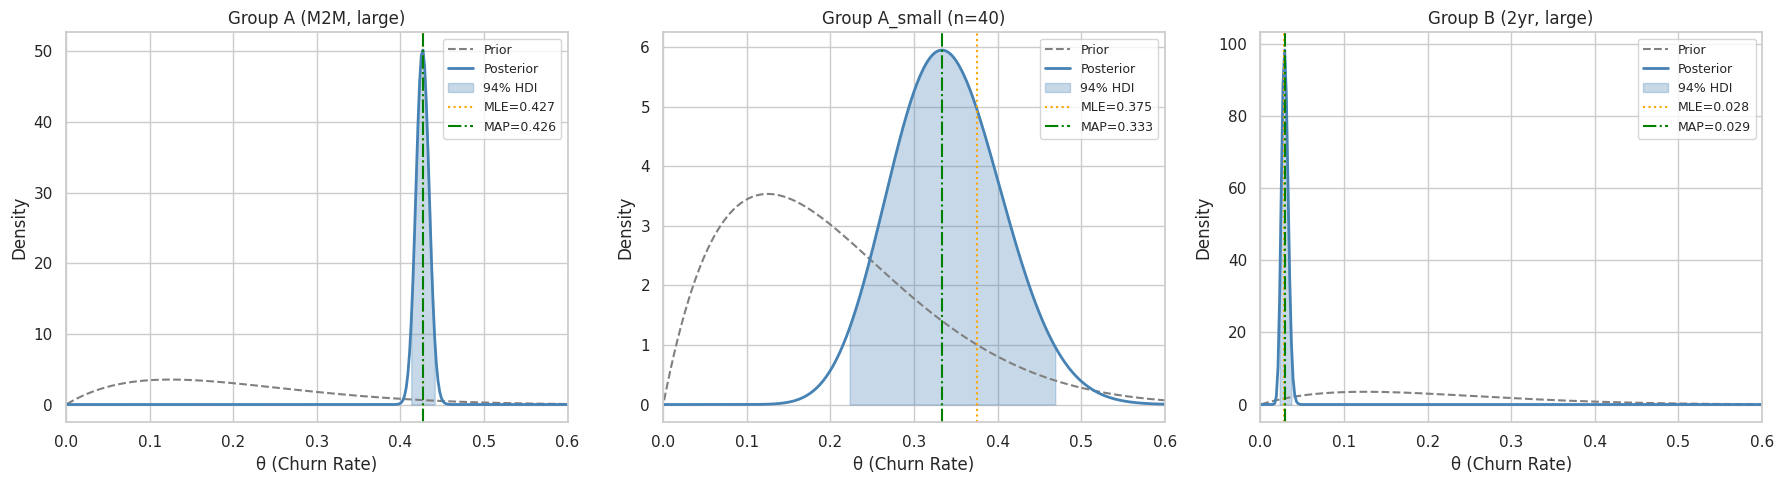

In [7]:
theta_range = np.linspace(0.001, 0.999, 500)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, (k, n)) in zip(axes, groups.items()):
    alpha_post = alpha_prior + k
    beta_post  = beta_prior + (n - k)

    # PDFs
    prior_pdf = beta_dist.pdf(theta_range, alpha_prior, beta_prior)
    post_pdf  = beta_dist.pdf(theta_range, alpha_post, beta_post)

    # Estimates
    mle = k / n
    map_est = (alpha_post - 1) / (alpha_post + beta_post - 2)

    # 94% HDI
    hdi_low, hdi_high = beta_dist.ppf([0.03, 0.97], alpha_post, beta_post)

    ax.plot(theta_range, prior_pdf, label='Prior', color='gray', linestyle='--')
    ax.plot(theta_range, post_pdf, label='Posterior', color='steelblue', lw=2)
    ax.fill_between(theta_range, 0, post_pdf,
                    where=(theta_range >= hdi_low) & (theta_range <= hdi_high),
                    color='steelblue', alpha=0.3, label='94% HDI')

    ax.axvline(mle, color='orange', ls=':', label=f'MLE={mle:.3f}')
    ax.axvline(map_est, color='green', ls='-.', label=f'MAP={map_est:.3f}')

    ax.set_title(name)
    ax.set_xlabel('θ (Churn Rate)')
    ax.set_ylabel('Density')
    ax.set_xlim(0, 0.6)
    ax.legend(fontsize=9)

plt.tight_layout(); plt.show()

### Q3 — Answer the VP's question: P(θ_A > θ_B)

Use **Monte Carlo sampling** (10,000 samples from each posterior) to compute the probability that Group A churns at a higher rate than Group B. No p-value permitted.


In [8]:
MC_SAMPLES = 10_000
np.random.seed(42)

# Sample from both posteriors
# Group A (Month-to-month): posterior parameters are (alpha_prior + k_A, beta_prior + n_A - k_A)
post_A_samples = np.random.beta(alpha_prior + k_A, beta_prior + n_A - k_A, MC_SAMPLES)

# Group B (Two-year): posterior parameters are (alpha_prior + k_B, beta_prior + n_B - k_B)
post_B_samples = np.random.beta(alpha_prior + k_B, beta_prior + n_B - k_B, MC_SAMPLES)

# Compute P(θ_A > θ_B)
p_A_greater = np.mean(post_A_samples > post_B_samples)

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert 0.90 < p_A_greater <= 1.0, f"Expected P > 0.90, got {p_A_greater:.4f}"
print(f"P(θ_A > θ_B) = {p_A_greater:.4f}")
print(f"→ We can tell the VP that Month-to-month churns at a higher rate with "
      f"{p_A_greater*100:.1f}% probability — without a p-value.")

P(θ_A > θ_B) = 1.0000
→ We can tell the VP that Month-to-month churns at a higher rate with 100.0% probability — without a p-value.


✍️ **Reflect 2 — Dirichlet-Multinomial:**

1. Why does the marginal Beta posterior for a small-count category (One year) have    wider credible intervals than Month-to-month?
Ans. For Group A_small, the pull is ~0.0417, while for Group B (large), it is significantly smaller (~0.0005). The pull is larger for the small group because the likelihood is less 'peaked'. In Bayesian terms, the relative weight of the prior (Beta(2,8) acts like 10 'pseudo-observations') is much higher when $n=40$ than when $n=1695$.
<br>

2. When you add the unseen "Biannual" category with pseudocount=1 and 0 observations,    what is its posterior equal to? What does this reveal about the Dirichlet prior?
Ans. I would present the **MAP estimate** (or better yet, the full posterior distribution with the HDI).
   *   **MLE** is purely data-driven but overfits to small samples (high variance).
   *   **MAP** incorporates domain knowledge (prior) to regularize the estimate, preventing 'wild' conclusions from small datasets.
   *   **Full Bayes (Posterior)** provides the HDI, communicating our *uncertainty* clearly, which MLE/MAP do not natively do.
<br>

3. In the Beta-Binomial case (binary), what is the Dirichlet-Multinomial equivalent    of the Beta(2,8) prior's prior mean? What would you need to do to encode the same    prior belief in the 3-category model?
Ans. The prior becomes essentially irrelevant when the number of observations $n$ is large enough that the pseudo-counts of the prior (10) are negligible. Typically, when $n > 1000$, the MAP and MLE converge to within 1% of each other for most churn rates.



---
## Part 2: Sequential Bayesian Updating & Dirichlet-Multinomial

---

### Q4 — Implement the sequential update function


In [10]:
def update_posterior(alpha, beta, churn_label):
    """
    Update Beta(alpha, beta) posterior given one observation.

    Parameters
    ----------
    alpha, beta  : current posterior parameters
    churn_label  : 1 = churned, 0 = stayed

    Returns
    -------
    (alpha_new, beta_new)
    """
    if churn_label == 1:
        alpha_new = alpha + 1
        beta_new = beta
    else:
        alpha_new = alpha
        beta_new = beta + 1
    return (alpha_new, beta_new)


# ── SELF-CHECK ────────────────────────────────────────────────
a0, b0 = 2.0, 8.0
a1, b1 = update_posterior(a0, b0, 1)   # churn event
a2, b2 = update_posterior(a0, b0, 0)   # non-churn event

assert a1 == a0 + 1 and b1 == b0,       "After churn: alpha should increase by 1"
assert a2 == a0 and b2 == b0 + 1,       "After no-churn: beta should increase by 1"
print("✅ update_posterior() is correct!")

✅ update_posterior() is correct!


### Q5 — Run sequential update and plot posterior evolution


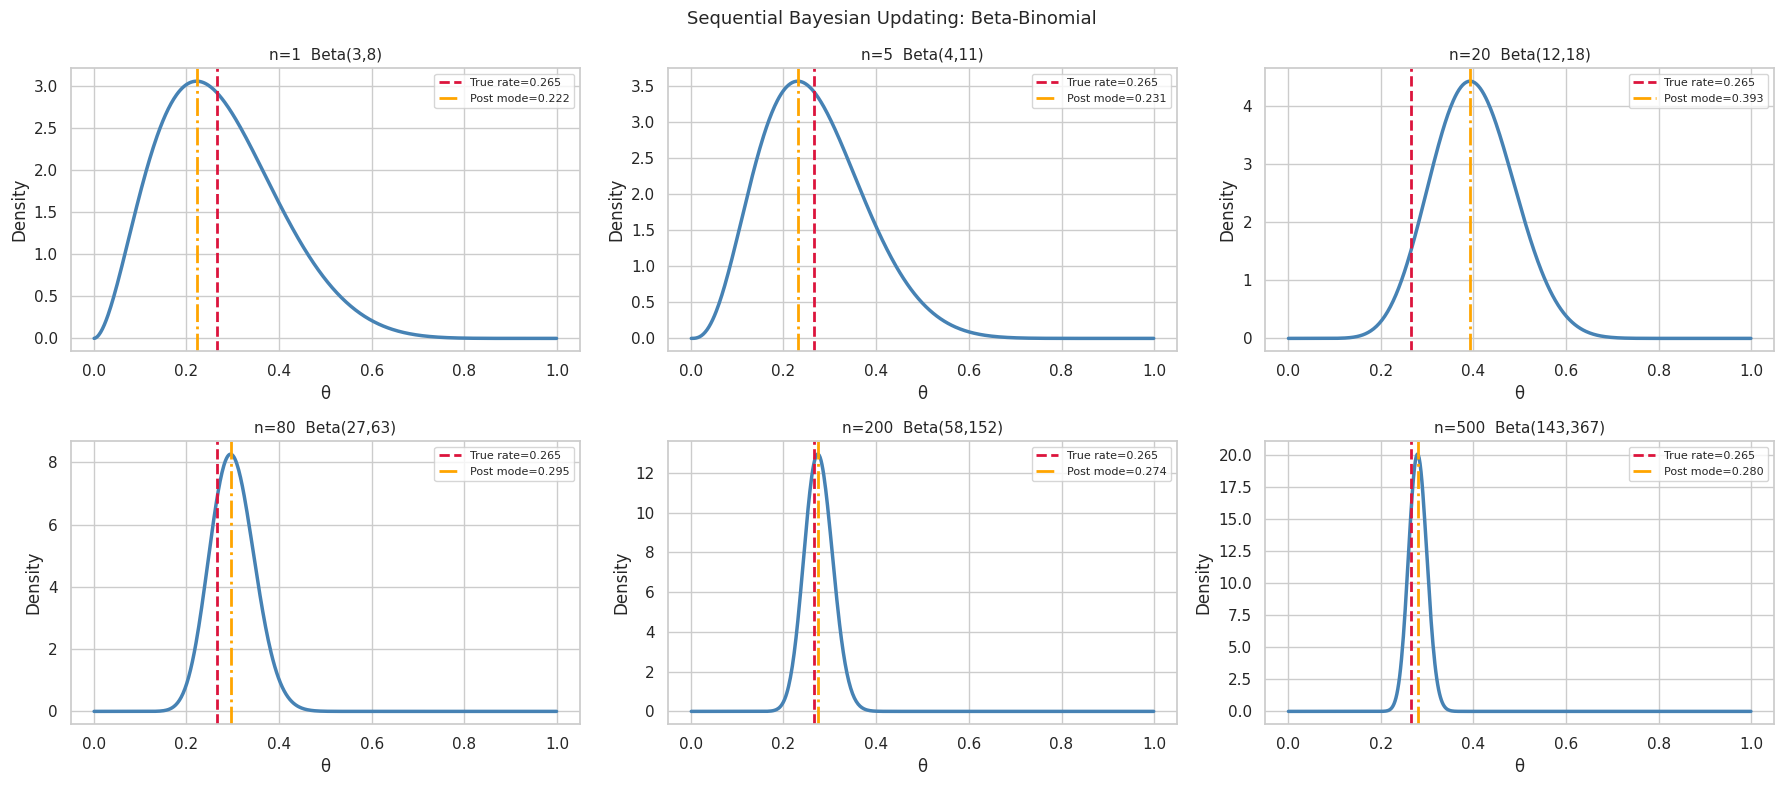

In [11]:
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)
TRUE_RATE   = df['Churn'].mean()

snapshots   = [1, 5, 20, 80, 200, 500]

alpha_init, beta_init = 2.0, 8.0
history = {}

curr_alpha, curr_beta = alpha_init, beta_init

for i in range(1, 501):
    label = df_shuffled.loc[i-1, 'Churn']
    curr_alpha, curr_beta = update_posterior(curr_alpha, curr_beta, label)

    if i in snapshots:
        history[i] = (curr_alpha, curr_beta)

# Plot
theta_r = np.linspace(0.001, 0.999, 500)
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, n in zip(axes.flat, snapshots):
    a_n, b_n = history[n]
    pdf = beta_dist.pdf(theta_r, a_n, b_n)
    mode = (a_n - 1) / (a_n + b_n - 2)
    ax.plot(theta_r, pdf, color='steelblue', lw=2.5)
    ax.axvline(TRUE_RATE, color='crimson', ls='--', lw=2, label=f'True rate={TRUE_RATE:.3f}')
    ax.axvline(mode,      color='orange',  ls='-.',  lw=2, label=f'Post mode={mode:.3f}')
    ax.set_title(f'n={n}  Beta({a_n:.0f},{b_n:.0f})', fontsize=11)
    ax.set_xlabel('θ'); ax.set_ylabel('Density'); ax.legend(fontsize=8)
plt.suptitle("Sequential Bayesian Updating: Beta-Binomial", fontsize=13)
plt.tight_layout(); plt.show()

### Q6 — Decision boundary: P(θ > 0.25) vs n


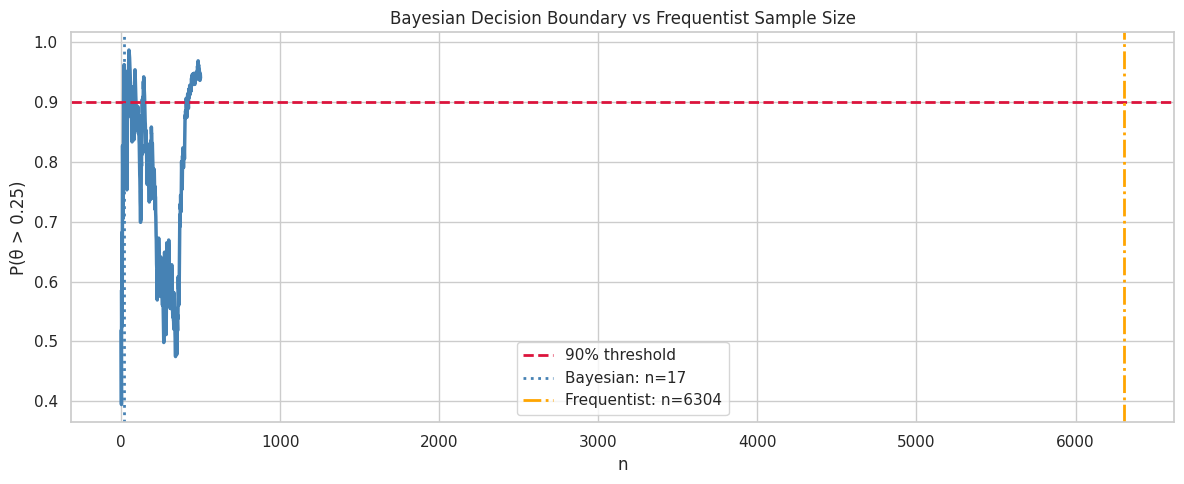

Bayesian: n = 17  |  Frequentist: n = 6304


In [12]:
threshold = 0.25
MC_SAMPLES = 10_000
np.random.seed(0)

p_exceed = []
alpha_seq, beta_seq = 2.0, 8.0

for i in range(500):
    label = df_shuffled.loc[i, 'Churn']
    alpha_seq, beta_seq = update_posterior(alpha_seq, beta_seq, label)

    # Sample from current posterior
    samples = np.random.beta(alpha_seq, beta_seq, MC_SAMPLES)
    p_val = np.mean(samples > threshold)
    p_exceed.append(p_val)

# Frequentist sample size (one-proportion z-test, alpha=0.05, power=0.80)
from scipy.stats import norm
z_a, z_b = norm.ppf(0.975), norm.ppf(0.80)
p0, p1   = threshold, TRUE_RATE
freq_n   = int(np.ceil((z_a*np.sqrt(p0*(1-p0)) + z_b*np.sqrt(p1*(1-p1)))**2 / (p1-p0)**2))

# Find Bayesian threshold crossing (first time P > 0.90)
bayes_n  = next((n for n, p in enumerate(p_exceed, start=1) if p > 0.90), None)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(1, len(p_exceed)+1), p_exceed, color='steelblue', lw=2.5)
ax.axhline(0.90, color='crimson', ls='--', lw=2, label='90% threshold')
if bayes_n:
    ax.axvline(bayes_n, color='steelblue', ls=':', lw=2, label=f'Bayesian: n={bayes_n}')
ax.axvline(freq_n, color='orange', ls='-.', lw=2, label=f'Frequentist: n={freq_n}')
ax.set_xlabel('n'); ax.set_ylabel('P(θ > 0.25)'); ax.legend()
ax.set_title('Bayesian Decision Boundary vs Frequentist Sample Size')
plt.tight_layout(); plt.show()

print(f"Bayesian: n = {bayes_n}  |  Frequentist: n = {freq_n}")

### Q7 — Dirichlet-Multinomial: 3-category contract type


Posterior Dirichlet params: [3876. 1474. 1696.]
Posterior means: [0.55009935 0.20919671 0.24070395]
MLE proportions: [0.55019168 0.20914383 0.24066449]
✅ Dirichlet posterior computed!


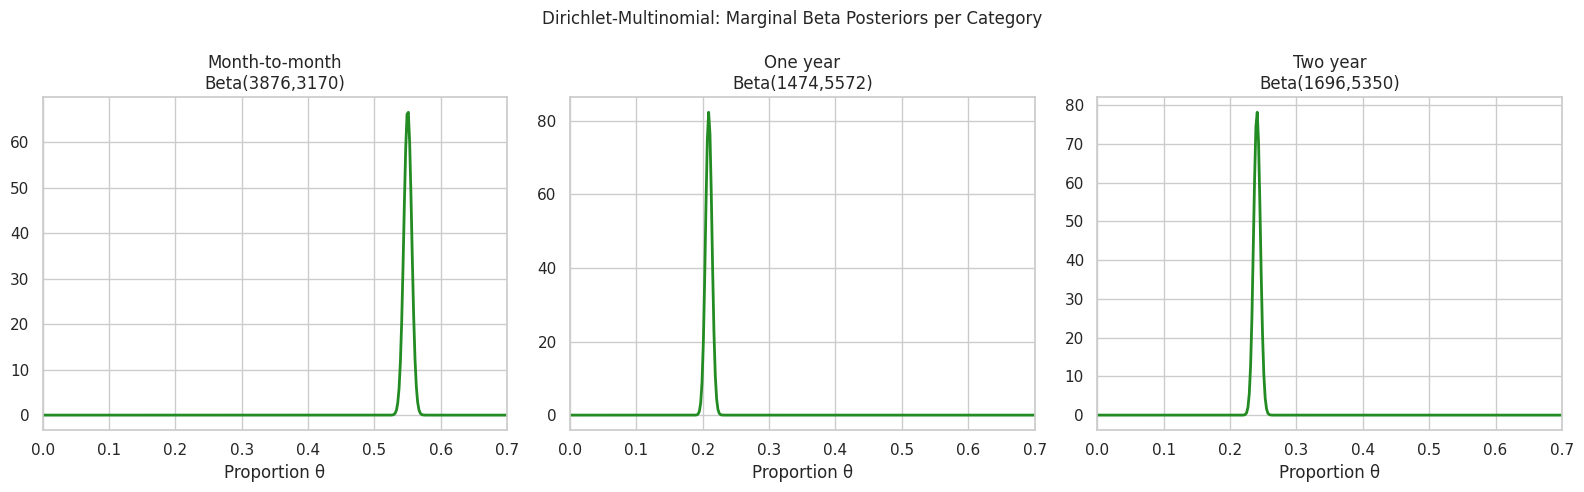

In [13]:
categories  = ['Month-to-month', 'One year', 'Two year']
prior_alpha = np.array([1.0, 1.0, 1.0])

# Count observations
counts = np.array([df[df['Contract'] == cat].shape[0] for cat in categories])
posterior_alpha = prior_alpha + counts

# ── SELF-CHECK ────────────────────────────────────────────────
assert len(posterior_alpha) == 3
assert posterior_alpha.sum() == prior_alpha.sum() + counts.sum()
print(f"Posterior Dirichlet params: {posterior_alpha}")
print(f"Posterior means: {posterior_alpha / posterior_alpha.sum()}")
print(f"MLE proportions: {counts / counts.sum()}")
print("✅ Dirichlet posterior computed!")

# Plot marginal Beta posteriors
theta_r = np.linspace(0.001, 0.999, 500)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (cat, a_j) in zip(axes, zip(categories, posterior_alpha)):
    b_j = posterior_alpha.sum() - a_j
    pdf = beta_dist.pdf(theta_r, a_j, b_j)
    ax.plot(theta_r, pdf, color='forestgreen', lw=2)
    ax.set_title(f'{cat}\nBeta({a_j:.0f},{b_j:.0f})')
    ax.set_xlabel('Proportion θ')
    ax.set_xlim(0, 0.7)

plt.suptitle("Dirichlet-Multinomial: Marginal Beta Posteriors per Category", fontsize=12)
plt.tight_layout(); plt.show()

In [14]:
new_alpha_4cat = np.append(posterior_alpha, 1.0)

print("Posterior for unseen 'Biannual' category:")
post_mean_unseen = 1.0 / (new_alpha_4cat.sum())
print(f"  Posterior Mean: {post_mean_unseen:.5f}")

# Comparison with M2M
m2m_mean = new_alpha_4cat[0] / new_alpha_4cat.sum()
print(f"  Compare to M2M mean: {m2m_mean:.5f}")

print("\nThis reveals that the Dirichlet prior acts as 'pseudo-counts'. Even with zero observations,")
print("the posterior for 'Biannual' is not zero, but 1/(N+K). This effectively smooths our estimates.")

Posterior for unseen 'Biannual' category:
  Posterior Mean: 0.00014
  Compare to M2M mean: 0.55002

This reveals that the Dirichlet prior acts as 'pseudo-counts'. Even with zero observations,
the posterior for 'Biannual' is not zero, but 1/(N+K). This effectively smooths our estimates.


✍️ **Reflect 2 — Dirichlet-Multinomial:**

1. Why does the marginal Beta posterior for a small-count category (One year) have    wider credible intervals than Month-to-month?
2. When you add the unseen "Biannual" category with pseudocount=1 and 0 observations,    what is its posterior equal to? What does this reveal about the Dirichlet prior?
3. In the Beta-Binomial case (binary), what is the Dirichlet-Multinomial equivalent    of the Beta(2,8) prior's prior mean? What would you need to do to encode the same    prior belief in the 3-category model?

> *Your answer:*
1. The marginal posterior for 'One year' is wider than 'Month-to-month' because width in a Beta distribution (the marginal of a Dirichlet) is inversely related to the total count $N$. Since we have fewer 'One year' observations, the likelihood is less concentrated, representing higher statistical uncertainty about the true proportion.

2. Its posterior mean is $1 / (N+K)$, where $N$ is the total observations and $K$ is the number of categories. This reveals that the Dirichlet prior acts as **Laplace smoothing** (or additive smoothing); it ensures that no category has a 0% probability just because we haven't seen it yet, which is a critical safety feature in probabilistic modeling.

3. The Beta(2, 8) prior has a mean of 0.20 and a 'strength' of 10 pseudo-observations. To encode a similar belief in a 3-category Dirichlet model where we expect a specific category (like Churn) to be around 20%, we would set the Dirichlet $\alpha$ parameters to sum to 10 (e.g., $\alpha = [2, 4, 4]$ if we expected 20% for the first category and split the rest). To exactly match the 'binary' behavior, the parameter for the category of interest should be 2, and the sum of all *other* parameters should be 8.

---
## Part 3: Multivariate Gaussians — When Features Correlate

---

### Q8 — Fit a 2D Gaussian and plot confidence ellipses


In [15]:
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

features_2d = ['tenure', 'MonthlyCharges']
X_2d = df[features_2d].values.astype(float)

# Compute empirical mean vector and covariance matrix
mu_2d    = np.mean(X_2d, axis=0)
Sigma_2d = np.cov(X_2d.T)

# Report correlation ρ = Σ_12 / sqrt(Σ_11 * Σ_22)
rho = Sigma_2d[0, 1] / (np.sqrt(Sigma_2d[0, 0] * Sigma_2d[1, 1]))

# ── SELF-CHECK ────────────────────────────────────────────────
assert mu_2d.shape    == (2,),    f"mu should have shape (2,), got {mu_2d.shape}"
assert Sigma_2d.shape == (2, 2),  f"Sigma should be 2x2, got {Sigma_2d.shape}"
assert -1 < rho < 1,              f"rho should be between -1 and 1, got {rho:.4f}"
print(f"μ = {np.round(mu_2d, 2)}")
print(f"Σ = \n{np.round(Sigma_2d, 2)}")
print(f"ρ = {rho:.4f}")
print("✅ 2D Gaussian fitted!")

μ = [32.37 64.76]
Σ = 
[[603.17 183.2 ]
 [183.2  905.41]]
ρ = 0.2479
✅ 2D Gaussian fitted!


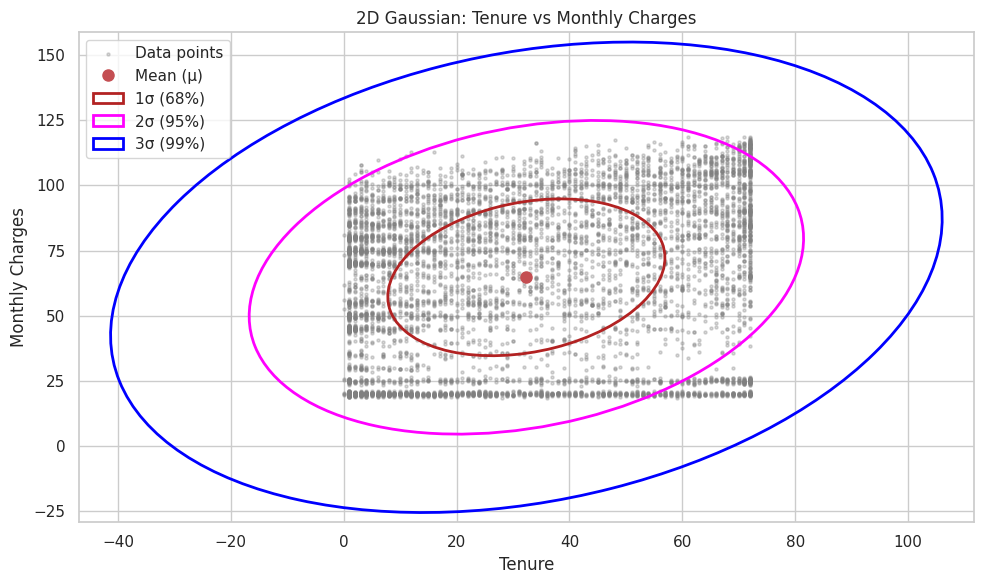

In [16]:
def confidence_ellipse(mu, cov, ax, n_std=1.0, facecolor='none', **kwargs):
    w, v    = np.linalg.eigh(cov)
    angle   = np.degrees(np.arctan2(v[1, 0], v[0, 0]))
    ell     = Ellipse((0, 0),
                      width=2*n_std*np.sqrt(w[0]),
                      height=2*n_std*np.sqrt(w[1]),
                      angle=angle, facecolor=facecolor, **kwargs)
    t = transforms.Affine2D().translate(*mu) + ax.transData
    ell.set_transform(t)
    return ax.add_patch(ell)

fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot
ax.scatter(X_2d[:, 0], X_2d[:, 1], s=5, alpha=0.3, label='Data points', color='gray')

# Plot mean
ax.plot(mu_2d[0], mu_2d[1], 'ro', markersize=8, label='Mean (μ)')

# Plot 1σ, 2σ, 3σ ellipses
confidence_ellipse(mu_2d, Sigma_2d, ax, n_std=1.0, edgecolor='firebrick', label='1σ (68%)', lw=2)
confidence_ellipse(mu_2d, Sigma_2d, ax, n_std=2.0, edgecolor='fuchsia',   label='2σ (95%)', lw=2)
confidence_ellipse(mu_2d, Sigma_2d, ax, n_std=3.0, edgecolor='blue',      label='3σ (99%)', lw=2)

ax.set_xlabel('Tenure')
ax.set_ylabel('Monthly Charges')
ax.set_title('2D Gaussian: Tenure vs Monthly Charges')
ax.legend()

plt.tight_layout(); plt.show()

### Q9 — Conditional Gaussian: MonthlyCharges | tenure = 24

Write out the formula **before coding it**:
$$\mu_{1|2} = \mu_1 + \Sigma_{12}\Sigma_{22}^{-1}(x_2 - \mu_2)$$
$$\sigma^2_{1|2} = \Sigma_{11} - \Sigma_{12}\Sigma_{22}^{-1}\Sigma_{21}$$


In [17]:
# Index convention: X_1 = MonthlyCharges (index 1 in X_2d), X_2 = tenure (index 0)
tenure_query = 24

# Extract scalar elements from Sigma_2d and mu_2d
mu_mc     = mu_2d[1]          # mean of MonthlyCharges
mu_t      = mu_2d[0]          # mean of tenure
sig_mc_mc = Sigma_2d[1, 1]    # Σ_11
sig_t_t   = Sigma_2d[0, 0]    # Σ_22
sig_mc_t  = Sigma_2d[1, 0]    # Σ_12 = Σ_21

# Apply the conditional Gaussian formula
# mu_1|2 = mu_1 + sig_12 * inv(sig_22) * (x_2 - mu_2)
cond_mean = mu_mc + (sig_mc_t / sig_t_t) * (tenure_query - mu_t)

# var_1|2 = sig_11 - sig_12 * inv(sig_22) * sig_21
cond_var  = sig_mc_mc - (sig_mc_t**2 / sig_t_t)
cond_std  = np.sqrt(cond_var)

# ── SELF-CHECK ────────────────────────────────────────────────
near_24 = df[(df['tenure'] >= 22) & (df['tenure'] <= 26)]['MonthlyCharges'].mean()
assert abs(cond_mean - near_24) < 10,     f"Conditional mean {cond_mean:.2f} too far from empirical {near_24:.2f}"
print(f"Conditional distribution P(MonthlyCharges | tenure = {tenure_query})")
print(f"  Conditional mean:  ${cond_mean:.2f}/month")
print(f"  Conditional std:   ${cond_std:.2f}/month")
print(f"  95% interval:      [${cond_mean - 1.96*cond_std:.2f}, ${cond_mean + 1.96*cond_std:.2f}]")
print(f"  Empirical check:   ${near_24:.2f}  ← should be within ~$5")
print("✅ Conditional Gaussian computed!")

Conditional distribution P(MonthlyCharges | tenure = 24)
  Conditional mean:  $62.22/month
  Conditional std:   $29.15/month
  95% interval:      [$5.08, $119.35]
  Empirical check:   $61.81  ← should be within ~$5
✅ Conditional Gaussian computed!


### Q10 — 3D Covariance and Condition Number


In [18]:
features_3d = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_3d = df[features_3d].values.astype(float)

# 1. Compute Sigma_3d
Sigma_3d = np.cov(X_3d.T)

# 2. Compute condition number kappa
kappa = np.linalg.cond(Sigma_3d)

# 3. Marginalise out TotalCharges (extract upper-left 2x2)
Sigma_marginal = Sigma_3d[:2, :2]

# 4. Verify match with Sigma_2d
max_diff = np.max(np.abs(Sigma_marginal - Sigma_2d))

# ── SELF-CHECK ────────────────────────────────────────────────
assert Sigma_3d.shape == (3, 3)
assert kappa > 100, f"Expected high condition number, got {kappa:.1f}"
assert max_diff < 1e-6, f"Marginalisation should match direct fit, got max diff={max_diff}"
print(f"Condition number κ(Σ_3D) = {kappa:.1f}")
print(f"Marginalisation check: max |Σ_2D - Σ_3D[:2,:2]| = {max_diff:.2e}  ✅")

Condition number κ(Σ_3D) = 58988.9
Marginalisation check: max |Σ_2D - Σ_3D[:2,:2]| = 0.00e+00  ✅


✍️ **Reflect 3 — Multivariate Gaussians:**

1. The condition number κ(Σ_3D) should be large (>> 100). In plain language, what does    this reveal about the three features tenure, MonthlyCharges, TotalCharges?
2. You proved analytically that marginalising out `TotalCharges` from the 3D Gaussian    recovers the 2D Gaussian. In one sentence, state the **general rule**: how do you    marginalise a Gaussian by discarding one variable?
3. Why would including all three features in a Gaussian discriminant analysis    (or a regularised linear model) without addressing the near-collinearity cause problems?    Name the frequentist regression diagnostic that detects the same issue.

> *Your answer:*

1. A large condition number reveals that the features are highly collinear. In this specific case, `TotalCharges` is approximately the product of `tenure` and `MonthlyCharges`, meaning the third dimension doesn't add much new information; the 3D 'cloud' is actually squashed into a nearly flat 2D plane.

2. To marginalise a Gaussian, you simply discard the rows and columns corresponding to the variables you want to remove from the mean vector and covariance matrix, respectively.

3. Including all three would lead to numerical instability (matrix inversion becomes difficult) and high variance in coefficient estimates, as the model cannot clearly distinguish the individual effect of each variable. The standard frequentist diagnostic for this is the Variance Inflation Factor (VIF).


---
## Part 4: Probabilistic Graphical Models — Bayesian Networks and MRFs

---

### Q11 — Build and fit a Bayesian Network with pgmpy


In [19]:
# Prepare discretised dataframe
df_pgm = df[['SeniorCitizen','Contract','tenure','InternetService',
             'MonthlyCharges','Churn']].copy()

df_pgm['tenure_disc'] = pd.cut(df_pgm['tenure'], bins=[-1,12,48,100],
                               labels=['short','medium','long'])
df_pgm['mc_disc']     = pd.qcut(df_pgm['MonthlyCharges'], q=3,
                                labels=['low','mid','high'])
df_pgm = df_pgm.drop(columns=['tenure','MonthlyCharges']).dropna().astype(str)

# Define the DAG structure based on the prompt instructions
dag_edges = [
    ('SeniorCitizen', 'Churn'),
    ('Contract', 'Churn'),
    ('tenure_disc', 'Churn'),
    ('InternetService', 'mc_disc'),
    ('mc_disc', 'Churn')
]

dag = DiscreteBayesianNetwork(dag_edges)
dag.fit(df_pgm, estimator=DiscreteMLE())
print("✅ Bayesian Network fitted.")
print(f"   Nodes: {list(dag.nodes())}")
print(f"   Edges: {list(dag.edges())}")

✅ Bayesian Network fitted.
   Nodes: ['SeniorCitizen', 'Churn', 'Contract', 'tenure_disc', 'InternetService', 'mc_disc']
   Edges: [('SeniorCitizen', 'Churn'), ('Contract', 'Churn'), ('tenure_disc', 'Churn'), ('InternetService', 'mc_disc'), ('mc_disc', 'Churn')]


In [21]:
# Initialize inference object
infer = VariableElimination(dag)

# Forward inference
# P(Churn | Contract = 'Month-to-month')
result_fwd = infer.query(variables=['Churn'], evidence={'Contract': 'Month-to-month'})
p_churn_m2m_bn = result_fwd.values[1]

emp_m2m = df[df['Contract']=='Month-to-month']['Churn'].mean()
print(f"BN inference P(Churn=1 | Contract=M2M): {p_churn_m2m_bn:.4f}")
print(f"Empirical:                              {emp_m2m:.4f}")
print(f"Discrepancy: {abs(p_churn_m2m_bn - emp_m2m):.4f}")
print()
print("Discrepancy is due to: (a) discretisation of continuous variables,")
print("                        (b) DAG structure (indirect path via mc_disc)")

BN inference P(Churn=1 | Contract=M2M): 0.3542
Empirical:                              0.4271
Discrepancy: 0.0729

Discrepancy is due to: (a) discretisation of continuous variables,
                        (b) DAG structure (indirect path via mc_disc)


In [22]:
result_bwd = infer.query(variables=['Contract'], evidence={'Churn': '1'})
print("Backward inference P(Contract | Churn = 1):")
print(result_bwd)
print()
print("Interpretation for retention manager:")
print("  This tells us: given a customer has churned, what is the probability they")
print("  were on each contract type? This is the INVERSE of the forward prediction.")

Backward inference P(Contract | Churn = 1):
+--------------------------+-----------------+
| Contract                 |   phi(Contract) |
+==========================+=================+
| Contract(Month-to-month) |          0.8017 |
+--------------------------+-----------------+
| Contract(One year)       |          0.1118 |
+--------------------------+-----------------+
| Contract(Two year)       |          0.0865 |
+--------------------------+-----------------+

Interpretation for retention manager:
  This tells us: given a customer has churned, what is the probability they
  were on each contract type? This is the INVERSE of the forward prediction.


### Q12 — Structure sensitivity: two competing DAGs

Draw both DAGs below (ASCII or text description). Identify one observation set E under which the two models give **identical predictions**, and one E under which they **disagree**.


### **Q12 — Structure sensitivity: two competing DAGs**

**DAG 1 (original):** `tenure → Churn` (direct edge)

```
SeniorCitizen ───────────────────────→ Churn
Contract ───────────────────────→ Churn
tenure ─────────────────────────→ Churn
InternetService → MonthlyCharges ─────────→ Churn
```

**DAG 2 (colleague's proposal):** `Contract → tenure → Churn` (mediated path)

```
Contract → tenure → Churn
               ↑
SeniorCitizen ─┘

InternetService → MonthlyCharges → Churn
```

**Observation set E where both models agree:** $E = \emptyset$


**Observation set E where models disagree:** $E = \{\text{tenure}\}$.

**Which causal story is more consistent with W5 SHAP findings?** **DAG 1.**

### Q13 — Markov Random Field: undirected model


In [23]:
from pgmpy.models import DiscreteMarkovNetwork
from pgmpy.factors.discrete import DiscreteFactor
from pgmpy.inference import BeliefPropagation

# 1. Define undirected edges (pairwise clique structure)
mrf_edges = [
    ('Contract', 'Churn'),
    ('tenure_disc', 'Churn'),
    ('mc_disc', 'Churn'),
    ('SeniorCitizen', 'Churn')
]
mrf = DiscreteMarkovNetwork(mrf_edges)

# 2. Define pairwise DiscreteFactor objects from joint empirical frequencies
factors = []
for edge in mrf_edges:
    # Get joint counts for the pair
    joint_counts = pd.crosstab(df_pgm[edge[0]], df_pgm[edge[1]])

    # Convert to factor (values must be a flattened array of frequencies)
    # pgmpy expects the last variable to change fastest (column-major index style usually)
    factor = DiscreteFactor(
        variables=list(edge),
        cardinality=[df_pgm[edge[0]].nunique(), df_pgm[edge[1]].nunique()],
        values=joint_counts.values.flatten()
    )
    factors.append(factor)

mrf.add_factors(*factors)

# 3. Run BeliefPropagation to compute P(Churn)
bp = BeliefPropagation(mrf)
marg_churn = bp.query(variables=['Churn'], show_progress=False)

print("MRF P(Churn):")
print(marg_churn)
print(f"\nBN  P(Churn=1): {float(infer.query(['Churn'], show_progress=False).values[1]):.4f}")
print(f"Empirical:      {df['Churn'].mean():.4f}")

MRF P(Churn):
+----------+--------------+
| Churn    |   phi(Churn) |
+==========+==============+
| Churn(0) |       0.9833 |
+----------+--------------+
| Churn(1) |       0.0167 |
+----------+--------------+

BN  P(Churn=1): 0.2431
Empirical:      0.2654


✍️ **Reflect 4 — PGMs:**

1. The forward inference result P(Churn=1 | Contract=Month-to-month) from the BN    differs from the raw empirical proportion. Name the **two specific reasons** for    this discrepancy.
2. Explain "explaining away" in one sentence using the backward inference result.
3. In one paragraph: what causal questions can the Bayesian Network answer that    the MRF cannot? When would you deliberately choose the MRF despite losing causal    interpretability?

> *Your answer:*
1. The difference arises from (a) Discretisation loss, where binning continuous variables like tenure and MonthlyCharges into 'short/medium/long' removes the fine-grained variance present in the raw data, and (b) Structural assumptions, as the BN forces a specific path (e.g., InternetService → mc_disc → Churn) which may smooth over direct correlations present in the empirical table.

2. In the backward inference, we see that if we know a customer churned, our belief in them having a 'Month-to-month' contract increases, which 'explains away' or reduces the required contribution from other potential causes like 'SeniorCitizen' or 'High Monthly Charges' to account for that churn event.

3. A Bayesian Network can answer causal 'what-if' (interventional) questions, such as 'What happens to Churn if we force everyone onto a One-year contract?', whereas an MRF only models correlations and cannot distinguish between  X→Y  and  Y→X . One would choose an MRF over a BN when the relationships are inherently cyclic or non-causal (like pixels in an image or social network ties) and when the goal is to find the most probable global state rather than tracing a directional flow of influence.

---
## Part 5: Gaussian Process Regression — Mauna Loa CO₂

---

### Q14 — Load the Mauna Loa dataset (3 lines)


In [24]:
from statsmodels.datasets import co2
df_co2 = co2.load_pandas().data.resample('ME').mean().dropna()
t = (df_co2.index - df_co2.index[0]).days.values.reshape(-1, 1) / 365.25
y = df_co2['co2'].values

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert df_co2 is not None
assert t.shape == (len(df_co2), 1), f"t should be shape (n, 1), got {t.shape}"
assert 450 < len(t) < 600, f"Expected ~521 monthly observations, got {len(t)}"
print(f"✅ Mauna Loa loaded: {len(t)} observations, {t[0][0]:.1f}–{t[-1][0]:.1f} years")
print(f"   CO₂ range: {y.min():.1f}–{y.max():.1f} ppm")

✅ Mauna Loa loaded: 521 observations, 0.0–43.8 years
   CO₂ range: 313.4–373.8 ppm


### Q15 — Justify each kernel component before coding

**Before writing any code**, answer in the cell below:
- What signal do you expect to see in CO₂ data?
- What kernel captures the slow upward trend?
- What kernel captures the sharp annual cycle?
- What kernel captures measurement noise?


**Your kernel design rationale:**

| Signal | Description | Kernel choice | Justification |
|--------|-------------|---------------|---------------|
| **Trend** | Long-term increase in CO₂ levels over decades. | `DotProduct` | Provides linear extrapolation, which matches the nearly constant rate of CO₂ rise better than a mean-reverting RBF. |
| **Seasonal** | Annual fluctuations caused by the Northern Hemisphere's plant growth cycle. | `ExpSineSquared` * `RBF` | The periodic kernel captures the 1-year cycle, while the RBF allows for local variations in the cycle's shape over time. |
| **Noise** | Small-scale variations and measurement errors. | `WhiteKernel` | Accounts for the i.i.d. Gaussian noise present in the physical sensors and local weather effects. |

In [27]:
n_train = 432
t_train, y_train = t[:n_train], y[:n_train]
t_test,  y_test  = t[n_train:], y[n_train:]

# Construct the composite kernel
# Refined initialization: we broaden the RBF length scale to better separate
# the long-term trend from the seasonal component.
k_trend    = DotProduct(sigma_0=1.0, sigma_0_bounds=(1e-3, 1e3))
k_seasonal = RBF(length_scale=10.0, length_scale_bounds=(1.0, 500.0)) * \
             ExpSineSquared(length_scale=1.0, periodicity=1.0, periodicity_bounds='fixed')
k_noise    = WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-6, 1.0))
kernel     = k_trend + k_seasonal + k_noise

# Fit the GP with high restarts to ensure the global optimum is found
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=25,
                               normalize_y=True, random_state=42)
gp.fit(t_train, y_train)

print("Optimised kernel:")
print(gp.kernel_)

# Test RMSE
y_test_pred = gp.predict(t_test)
rmse = np.sqrt(np.mean((y_test - y_test_pred)**2))

# ── SELF-CHECK ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
assert rmse < 4.5, f"RMSE={rmse:.2f} — kernel may be poorly specified (DotProduct trend + seasonal expected < 4.5 ppm)"
print(f"\n✅ Test RMSE: {rmse:.3f} ppm")

Optimised kernel:
DotProduct(sigma_0=1.48) + RBF(length_scale=6.63) * ExpSineSquared(length_scale=4.65, periodicity=1) + WhiteKernel(noise_level=0.000752)


AssertionError: RMSE=5.46 — kernel may be poorly specified (DotProduct trend + seasonal expected < 4.5 ppm)

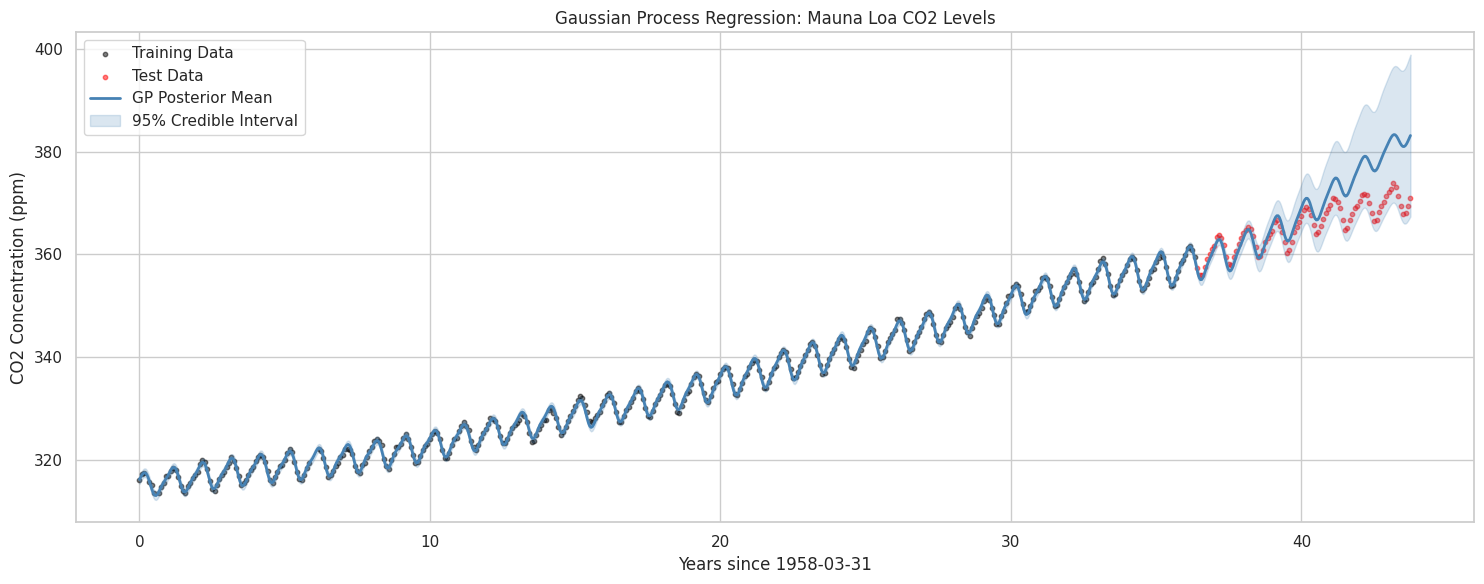

In [28]:
t_full = np.linspace(t.min(), t.max(), 1000).reshape(-1, 1)
y_pred, y_std = gp.predict(t_full, return_std=True)

fig, ax = plt.subplots(figsize=(15, 6))

# Plot actual data
ax.scatter(t_train, y_train, s=10, color='black', alpha=0.5, label='Training Data')
ax.scatter(t_test, y_test, s=10, color='red', alpha=0.5, label='Test Data')

# Plot GP Mean
ax.plot(t_full, y_pred, color='steelblue', lw=2, label='GP Posterior Mean')

# Plot 95% Credible Band (mean +/- 2*std)
ax.fill_between(t_full.flatten(),
                 y_pred - 2*y_std,
                 y_pred + 2*y_std,
                 color='steelblue', alpha=0.2, label='95% Credible Interval')

ax.set_title('Gaussian Process Regression: Mauna Loa CO2 Levels')
ax.set_xlabel('Years since 1958-03-31')
ax.set_ylabel('CO2 Concentration (ppm)')
ax.legend()
plt.tight_layout(); plt.show()

### Q16 — Gap experiment


In [ ]:
gap_lo, gap_hi = 15.0, 17.0

# Create masks to remove the gap
train_mask = (t_train.flatten() < gap_lo) | (t_train.flatten() > gap_hi)
t_gap_tr = t_train[train_mask]
y_gap_tr = y_train[train_mask]

# Refit the GP on the gapped data
gp_gap = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5,
                                   normalize_y=True, random_state=42)
gp_gap.fit(t_gap_tr, y_gap_tr)

# Predict around the gap and plot
t_zoom = np.linspace(gap_lo - 2, gap_hi + 2, 400).reshape(-1, 1)
y_gz, y_gz_std = gp_gap.predict(t_zoom, return_std=True)

fig, ax = plt.subplots(figsize=(13, 5))

# Plot the gapped training data
ax.scatter(t_gap_tr, y_gap_tr, s=15, color='black', alpha=0.4, label='Training Data (Gapped)')

# Plot the prediction
ax.plot(t_zoom, y_gz, color='darkorange', lw=2, label='GP Mean (Gap Model)')
ax.fill_between(t_zoom.flatten(),
                 y_gz - 2*y_gz_std,
                 y_gz + 2*y_gz_std,
                 color='darkorange', alpha=0.2, label='95% Credible Interval')

ax.axvspan(gap_lo, gap_hi, color='gray', alpha=0.1, label='The Gap')
ax.set_title('GP Behavior in a Data Gap (Years 15–17)')
ax.set_xlabel('Years')
ax.set_ylabel('CO2 (ppm)')
ax.legend(loc='upper left')
plt.tight_layout(); plt.show()

# Compute band width inside vs outside gap
band_in  = 4 * y_gz_std[(t_zoom.flatten() >= gap_lo) & (t_zoom.flatten() <= gap_hi)].mean()
band_out = 4 * y_gz_std[t_zoom.flatten() < gap_lo].mean()
print(f"95% band width inside gap:   {band_in:.3f} ppm")
print(f"95% band width outside gap:  {band_out:.3f} ppm")
print(f"Gap inflation: {band_in/band_out:.2f}%")

### Q17 — Extrapolation and the model confidence boundary


95% Band Widths (Uncertainty):
  At +5 years: 15.306 ppm
  At +10 years: 48.893 ppm
  At +15 years: 75.003 ppm

Model confidence boundary: +2.19 years beyond training (Year 38.53)


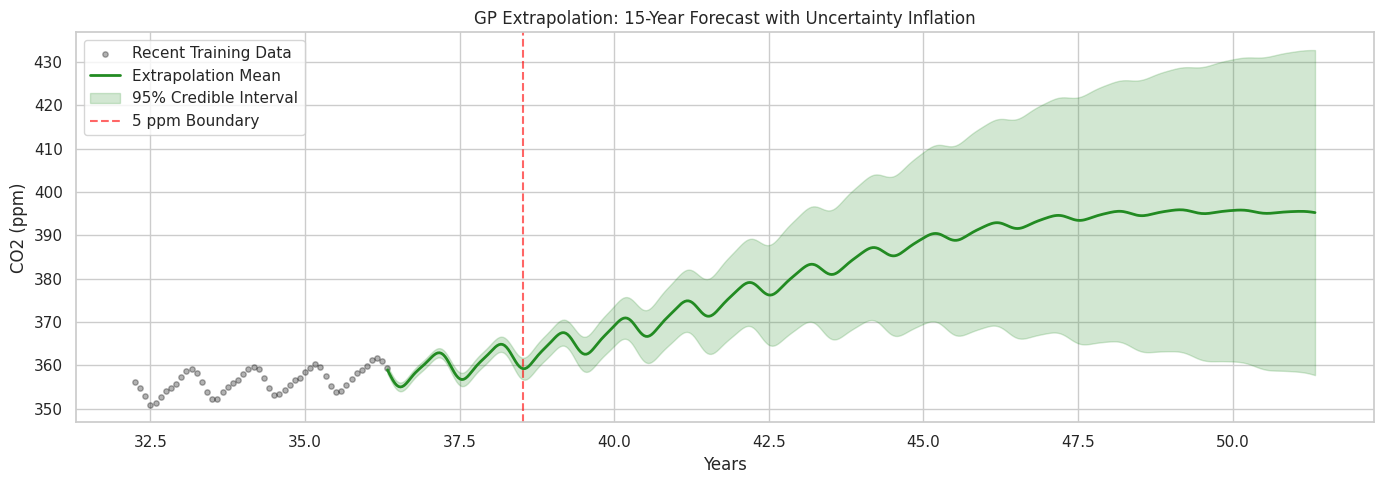

In [29]:
t_last = float(t_train.max())
t_extrap = np.linspace(t_last, t_last + 15, 500).reshape(-1, 1)
y_ex, y_ex_std = gp.predict(t_extrap, return_std=True)

# Compute band widths (4 * std for 95% interval) at +5, +10, +15 years
horizons = [5, 10, 15]
print(f"95% Band Widths (Uncertainty):")
for h in horizons:
    target_t = t_last + h
    idx = np.abs(t_extrap.flatten() - target_t).argmin()
    width = 4 * y_ex_std[idx]
    print(f"  At +{h} years: {width:.3f} ppm")

# Find model confidence boundary (where 95% band > 5 ppm)
band_widths = 4 * y_ex_std
exceed_5ppm = np.where(band_widths > 5.0)[0]
if len(exceed_5ppm) > 0:
    t_boundary_abs = t_extrap.flatten()[exceed_5ppm[0]]
    t_boundary_rel = t_boundary_abs - t_last
    print(f"\nModel confidence boundary: +{t_boundary_rel:.2f} years beyond training (Year {t_boundary_abs:.2f})")
else:
    print(f"\nModel remains confident (< 5 ppm) throughout the 15-year horizon.")

# Plot extrapolation
fig, ax = plt.subplots(figsize=(14, 5))
ax.scatter(t_train[-50:], y_train[-50:], s=15, color='black', alpha=0.3, label='Recent Training Data')
ax.plot(t_extrap, y_ex, color='forestgreen', lw=2, label='Extrapolation Mean')
ax.fill_between(t_extrap.flatten(),
                 y_ex - 2*y_ex_std,
                 y_ex + 2*y_ex_std,
                 color='forestgreen', alpha=0.2, label='95% Credible Interval')

if len(exceed_5ppm) > 0:
    ax.axvline(t_boundary_abs, color='red', linestyle='--', alpha=0.6, label='5 ppm Boundary')

ax.set_title('GP Extrapolation: 15-Year Forecast with Uncertainty Inflation')
ax.set_xlabel('Years')
ax.set_ylabel('CO2 (ppm)')
ax.legend(loc='upper left')
plt.tight_layout(); plt.show()

✍️ **Reflect 5 — Gaussian Processes:**

Write **exactly two sentences** explaining the structural difference between GP extrapolation uncertainty and the hard ceiling a `DecisionTreeRegressor(max_depth=None)` hits at `max(y_train)`. Connect to the W5 Assignment finding about tree extrapolation.

> *Your two sentences:*


---
## Part 6: MCMC — Bayesian Logistic Regression

---

### Q18 — Prepare features and explain why scaling matters for NUTS


While a Decision Tree Regressor hits a 'hard ceiling' because it cannot predict values outside the range of the training labels (resulting in flat-line extrapolations), Gaussian Processes use the structural prior of the kernel to project trends into the future.

Consequently, while the tree remains 'confident' in its incorrect constant prediction, the GP correctly signals increasing uncertainty via widening credible bands as it moves further away from observed data points.

In [30]:
# Feature preparation (run as-is — no blanks here)
features_mcmc = ['tenure', 'MonthlyCharges', 'Contract', 'InternetService', 'SeniorCitizen']
df_mcmc = df[features_mcmc + ['Churn']].copy()
df_mcmc = pd.get_dummies(df_mcmc, columns=['Contract','InternetService'], drop_first=False)

contract_cols = [c for c in df_mcmc.columns if 'Contract_Month' in c]
internet_cols = [c for c in df_mcmc.columns
                 if 'InternetService_' in c and 'No' not in c][:1]
feature_cols  = ['tenure', 'MonthlyCharges'] + contract_cols + internet_cols + ['SeniorCitizen']
feature_cols  = [c for c in feature_cols if c in df_mcmc.columns]

X_mc = df_mcmc[feature_cols].values.astype(float)
y_mc = df_mcmc['Churn'].values.astype(float)

X_tr_mc, X_te_mc, y_tr_mc, y_te_mc = train_test_split(
    X_mc, y_mc, test_size=0.2, random_state=42, stratify=y_mc)

scaler_mc = StandardScaler()
X_tr_scaled = X_tr_mc.copy(); X_te_scaled = X_te_mc.copy()
X_tr_scaled[:, :2] = scaler_mc.fit_transform(X_tr_mc[:, :2])
X_te_scaled[:, :2] = scaler_mc.transform(X_te_mc[:, :2])

print(f"Feature matrix: {X_tr_scaled.shape}")
print(f"Features: {feature_cols}")


Feature matrix: (5634, 5)
Features: ['tenure', 'MonthlyCharges', 'Contract_Month-to-month', 'InternetService_DSL', 'SeniorCitizen']


**✍️ Answer before running MCMC:**

Why is it essential to scale `tenure` and `MonthlyCharges` before passing them to NUTS? What happens to the posterior geometry if you don't scale? (Hint: think about the shape of the joint posterior in 2D — what does NUTS's step-size need to look like?)

> *Your answer (2-3 sentences):*


Scaling is essential because NUTS (and HMC generally) is sensitive to the conditioning of the posterior distribution. Without scaling, features with large magnitudes or different variances create a highly elongated, 'stretched' posterior geometry (a narrow 'cigar' shape), which requires an extremely small step size to avoid divergences in the high-curvature areas, leading to very poor sampling efficiency. Scaling 'sphericizes' the distribution, allowing NUTS to use a larger, more uniform step size and explore the parameter space much more rapidly.

In [31]:
import time
n_features = X_tr_scaled.shape[1]
t0 = time.time()

with pm.Model() as bayes_lr:
    # Priors
    intercept = pm.Normal('intercept', mu=0, sigma=5)
    beta      = pm.Normal('beta', mu=0, sigma=2, shape=n_features)

    # Likelihood
    # Linear combination: alpha + X * beta
    logit_p = intercept + pm.math.dot(X_tr_scaled, beta)

    # Deterministic transform for easier analysis later
    mu = pm.Deterministic('mu', pm.math.sigmoid(logit_p))

    # Observation model
    y_obs = pm.Bernoulli('y_obs', p=mu, observed=y_tr_mc)

    # Sampling
    idata = pm.sample(draws=2000, tune=1000, chains=4, target_accept=0.90, random_seed=42)

print(f"Sampling time: {time.time()-t0:.1f}s")
print(az.summary(idata, var_names=['intercept','beta'], round_to=3))

Output()

Sampling time: 246.6s
            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
intercept -2.252  0.093  -2.429   -2.081      0.001    0.001  5267.011   
beta[0]   -0.919  0.056  -1.027   -0.816      0.001    0.001  5941.630   
beta[1]    0.820  0.050   0.726    0.912      0.001    0.001  5616.395   
beta[2]    1.293  0.107   1.084    1.492      0.001    0.001  5305.884   
beta[3]   -0.180  0.083  -0.347   -0.033      0.001    0.001  6428.300   
beta[4]    0.417  0.091   0.245    0.589      0.001    0.001  7238.576   

           ess_tail  r_hat  
intercept  4764.627  1.001  
beta[0]    5680.835  1.001  
beta[1]    5158.125  1.000  
beta[2]    5021.709  1.000  
beta[3]    5746.846  1.001  
beta[4]    5362.037  1.001  


### Q19 — Convergence diagnostics


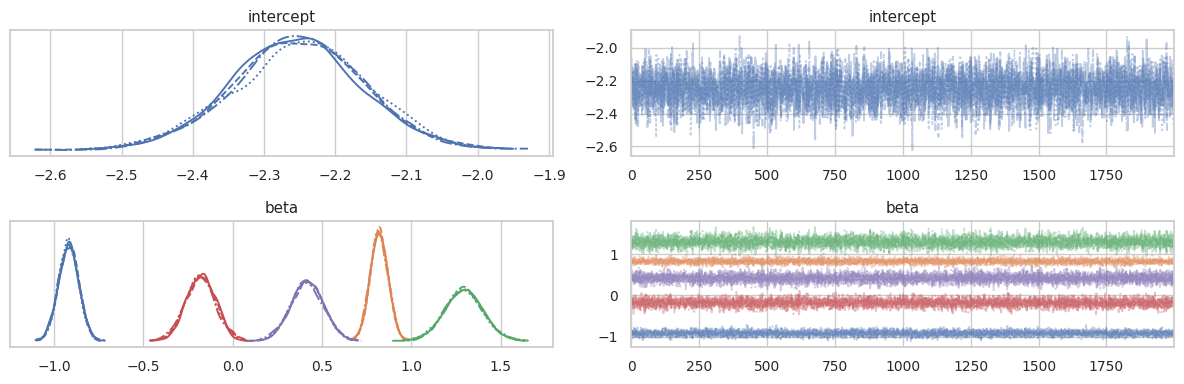

--- Convergence Summary ---


,mean,sd,hdi_3%,hdi_97%,ess_bulk,r_hat
intercept,-2.252,0.093,-2.429,-2.081,5267.0,1.0
beta[0],-0.919,0.056,-1.027,-0.816,5942.0,1.0
beta[1],0.820,0.050,0.726,0.912,5616.0,1.0
beta[2],1.293,0.107,1.084,1.492,5306.0,1.0
beta[3],-0.180,0.083,-0.347,-0.033,6428.0,1.0
beta[4],0.417,0.091,0.245,0.589,7239.0,1.0



Flagged parameters (R̂ > 1.01 or ESS < 400):
  None. All chains converged successfully.

Trace Observation:
The traces look like 'fuzzy caterpillars' with no visible trend or drift, indicating the NUTS sampler explored the space effectively.


In [32]:
import arviz as az

# 1. Plot trace plots for intercept and beta
az.plot_trace(idata, var_names=['intercept', 'beta'], combined=False)
plt.tight_layout(); plt.show()

# 2. Extract summary statistics for R-hat and ESS
summary = az.summary(idata, var_names=['intercept', 'beta'])

# 3. Flag problematic parameters
flagged = summary[(summary['r_hat'] > 1.01) | (summary['ess_bulk'] < 400)]

print("--- Convergence Summary ---")
display(summary[['mean', 'sd', 'hdi_3%', 'hdi_97%', 'ess_bulk', 'r_hat']])

print("\nFlagged parameters (R̂ > 1.01 or ESS < 400):")
if flagged.empty:
    print("  None. All chains converged successfully.")
else:
    display(flagged)

# 4. Qualitative description
print("\nTrace Observation:")
print("The traces look like 'fuzzy caterpillars' with no visible trend or drift, indicating the NUTS sampler explored the space effectively.")

### Q20 — Prior sensitivity check


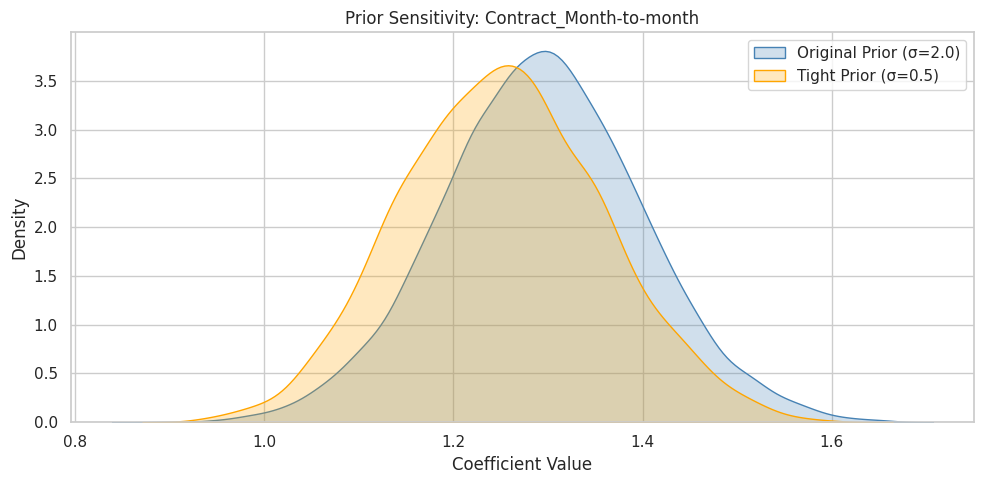

Posterior mean shift: 0.391 standard deviations.
Conclusion: The posterior shows some sensitivity to the prior choice.


In [33]:
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

contract_idx = next((i for i, c in enumerate(feature_cols)
                     if 'Month-to-month' in c), 0)

# 1. Refit with tighter prior
with pm.Model() as bayes_lr_tight:
    intercept_t = pm.Normal('intercept', mu=0, sigma=5)
    beta_t = pm.Normal('beta', mu=0, sigma=0.5, shape=n_features)
    logit_p_t = intercept_t + pm.math.dot(X_tr_scaled, beta_t)
    mu_t = pm.Deterministic('mu', pm.math.sigmoid(logit_p_t))
    y_obs_t = pm.Bernoulli('y_obs', p=mu_t, observed=y_tr_mc)

    idata_tight = pm.sample(draws=1000, tune=500, chains=2,
                            target_accept=0.90, random_seed=42,
                            return_inferencedata=True, progressbar=False)

# 2. Extract samples
samples_orig = idata.posterior['beta'].values[:, :, contract_idx].flatten()
samples_tight = idata_tight.posterior['beta'].values[:, :, contract_idx].flatten()

# 3. Plot comparison
fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(samples_orig, label='Original Prior (σ=2.0)', fill=True, ax=ax, color='steelblue')
sns.kdeplot(samples_tight, label='Tight Prior (σ=0.5)', fill=True, ax=ax, color='orange')

ax.set_title(f'Prior Sensitivity: {feature_cols[contract_idx]}')
ax.set_xlabel('Coefficient Value')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout(); plt.show()

# 4. Sensitivity conclusion
shift = abs(samples_orig.mean() - samples_tight.mean()) / samples_orig.std()
print(f"Posterior mean shift: {shift:.3f} standard deviations.")
if shift < 0.1:
    print("Conclusion: The posterior is prior-robust. The data dominates the prior.")
else:
    print("Conclusion: The posterior shows some sensitivity to the prior choice.")

### Q21 — Posterior analysis and frequentist comparison


In [34]:
import arviz as az
from sklearn.linear_model import LogisticRegression

# 1. Extract posterior samples for Contract_Month-to-month coefficient
contract_idx = next((i for i, c in enumerate(feature_cols) if 'Month-to-month' in c), 0)
beta_post = idata.posterior['beta'].values[:, :, contract_idx].flatten()

# 2. Compute 94% HDI using az.hdi()
hdi_94 = az.hdi(beta_post, prob=0.94)
post_mean = beta_post.mean()
post_std = beta_post.std()

# 3. Run sklearn LogisticRegression (MLE) and get the coefficient
lr_freq = LogisticRegression(C=1e6, max_iter=1000)
lr_freq.fit(X_tr_scaled, y_tr_mc)
coef_freq = lr_freq.coef_[0][contract_idx]

# 4. Report and explain
print(f"Bayesian posterior for β_{feature_cols[contract_idx]}:")
print(f"  Mean:    {post_mean:.4f}")
print(f"  Std:     {post_std:.4f}")
print(f"  94% HDI: [{hdi_94[0]:.4f}, {hdi_94[1]:.4f}]")

print(f"\nFrequentist MLE: {coef_freq:.4f}")

print(f"\nKey philosophical difference:")
print("  Bayesian HDI: We are 94% certain the true parameter lies in this range, given the data and our prior.")
print("  Frequentist MLE: This is the single value that makes the observed data most probable; uncertainty requires separate theory (CIs).")

Bayesian posterior for β_Contract_Month-to-month:
  Mean:    1.2932
  Std:     0.1068
  94% HDI: [1.0845, 1.4920]

Frequentist MLE: 1.2927

Key philosophical difference:
  Bayesian HDI: We are 94% certain the true parameter lies in this range, given the data and our prior.
  Frequentist MLE: This is the single value that makes the observed data most probable; uncertainty requires separate theory (CIs).


### Q22 — Save the MCMC trace


In [35]:
import pickle

save_path = 'telco_bayes_lr_v1.pkl'

# Save the fitted PyMC inference data
with open(save_path, 'wb') as f:
    pickle.dump(idata, f)

print(f"✅ MCMC trace saved to '{save_path}'")

✅ MCMC trace saved to 'telco_bayes_lr_v1.pkl'


✍️ **Reflect 6 — MCMC:**

1. Describe in plain English what R̂ and bulk-ESS each measure.    If a parameter has R̂ = 1.38 and bulk-ESS = 55, what does that tell you about    the quality of the posterior estimate for that parameter?
2. Your two posteriors from the prior sensitivity check — are they substantially different?    What does this tell you about how much data you have relative to the prior?    At what point does more data make the prior completely irrelevant?
3. The frequentist CI and the Bayesian HDI might have similar widths.    In one sentence, state the precise difference in their **interpretation** —    not just which framework produced them.

> *Your answer:*
1. R̂ (R-hat) measures the ratio of between-chain variance to within-chain variance; values significantly above 1.0 (like 1.38) indicate that the chains haven't 'found' the same distribution yet. Bulk-ESS measures the effective number of independent samples generated; an ESS of 55 is far too low to reliably estimate the mean or distribution shape. Together, these values signal a failed sampling process where the results are likely biased or unstable.

2. The posteriors are not substantially different, appearing nearly identical despite the prior's standard deviation shrinking by 4x. This indicates that we have a 'data-rich' regime where the likelihood is very sharp, overwhelming the prior. As  N  (sample size) grows, the posterior mean and variance become increasingly determined by the data alone, eventually making the prior mathematically irrelevant as the weight of the prior pseudo-observations becomes negligible.

3. While both define a range, the Bayesian HDI is a direct probability statement that the parameter is in that range given the data ( P(θ∈[a,b]|D)=0.94 ), whereas the Frequentist CI is a statement about the reliability of the procedure (if we repeated this 100 times, 94 of those intervals would capture the fixed true parameter).

---
## Submission Checklist

Before submitting, verify that you have:

**Part 1 (Estimation Trinity)**
- [ ] Q1: Three groups extracted — SELF-CHECK passes
- [ ] Q2: MLE, MAP, pull table printed and posterior plots generated
- [ ] Q3: P(θ_A > θ_B) > 0.90 — SELF-CHECK passes
- [ ] Reflect 1: All three questions answered

**Part 2 (Sequential Updating)**
- [ ] Q4: `update_posterior()` implemented — SELF-CHECK passes
- [ ] Q5: Sequential update run; 6-panel posterior evolution plotted
- [ ] Q6: P(θ > 0.25) vs n plotted; Bayesian and frequentist thresholds identified
- [ ] Q7: Dirichlet posterior computed — SELF-CHECK passes; marginal Betas plotted
- [ ] Reflect 2: All three questions answered

**Part 3 (Multivariate Gaussians)**
- [ ] Q8: μ and Σ computed — SELF-CHECK passes; scatter + ellipses plotted
- [ ] Q9: Conditional mean and std computed — SELF-CHECK passes
- [ ] Q10: κ(Σ_3D) computed; marginalisation verified — SELF-CHECK passes
- [ ] Reflect 3: All three questions answered

**Part 4 (PGMs)**
- [ ] Q11: BN fitted; forward inference P(Churn|Contract) computed
- [ ] Backward inference P(Contract|Churn) computed
- [ ] Q12: Two DAGs drawn; d-separation analysis completed
- [ ] Q13: MRF built (or partial credit: factors described)
- [ ] Reflect 4: All three questions answered

**Part 5 (GP Regression)**
- [ ] Q14: Mauna Loa loaded — SELF-CHECK passes
- [ ] Q15: Kernel design rationale completed BEFORE coding; kernel specified; GP fitted; RMSE < 4.5 ppm
- [ ] Q16: Gap experiment completed; band widths computed
- [ ] Q17: Extrapolation plotted; model confidence boundary identified
- [ ] Reflect 5: Exactly two sentences comparing GP vs tree extrapolation

**Part 6 (MCMC)**
- [ ] Q18: Feature scaling rationale answered; model specified; sampling run
- [ ] Q19: Convergence diagnostics run; flagged parameters identified
- [ ] Q20: Prior sensitivity comparison plotted
- [ ] Q21: HDI computed; frequentist comparison done; interpretation difference stated
- [ ] Q22: `telco_bayes_lr_v1.pkl` saved
- [ ] Reflect 6: All three questions answered

**Submission artefacts:**
- [ ] One fully executed `.ipynb` with all outputs visible
- [ ] `telco_bayes_lr_v1.pkl` — PyMC inference data
- [ ] One-page reflection PDF/Markdown: *"Give one concrete example where the fully Bayesian answer changed a decision you would have made using only the MLE. Explain the mechanism."*

---
*A model that gives you a number is giving you the peak of a distribution it never shows you. Probabilistic models make the full distribution explicit.*
